In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt

# Likelihood (Правдоподобие). 
## Вероятность получить значение из популяции. Вероятность популяции при заданном значении.

In [14]:
params = {
    'mu_1': 50,
    'sigma_1': 10,
    'mu_2': 55,
    'sigma_2': 10,
}

In [15]:
def get_population(mu_1, sigma_1, mu_2, sigma_2, size=1_000_000):
    """Формируем две популяции с необходимыми параметрами"""

    rng = np.random.default_rng(seed=42)
    population_1 = rng.normal(size=size, loc=mu_1, scale=sigma_1)
    population_2 = rng.normal(size=size, loc=mu_2, scale=sigma_2)

    return population_1, population_2

In [26]:
def show_value(data1, data2, value, mu_1, sigma_1, mu_2, sigma_2):
    """Считаем вероятность "значения из популяции/популяции при значении" и визуализируем распределения"""

    # Посчитаем вероятность получить значение из популяции
    probability_1 = stats.norm.pdf(value, loc=mu_1, scale=sigma_1)
    probability_2 = stats.norm.pdf(value, loc=mu_2, scale=sigma_2)

    print(
        f'Вероятность получить значение {value} из Популяции №1 : {probability_1:.2%}\n'
        f'Вероятность получить значение {value} из Популяции №2 : {probability_2:.2%}\n'
    )

    # Построение гистограмм для двух выборок на одном графике
    plt.figure(figsize=(12, 5))
    sns.histplot(data1, kde=True, stat="probability", color='orange', label='population_1', alpha=0.9)
    sns.histplot(data2, kde=True, stat="probability", color='blue', label='population_2', alpha=0.3)

    # Добавляем вертикальную линию для выбранного значения
    plt.axvline(x=value, color='red', linestyle='--', label=f'Значение {value}')

    # Настроим подписи и легенду
    plt.xlabel('Значение')
    plt.ylabel('Вероятность')
    plt.legend()
    plt.title(f'Распределение вероятностей получить значение {value} из разных популяций')

    plt.show()

In [27]:
# Генерируем популяции 
population_1, population_2 = get_population(**params)

Вероятность получить значение 45 из Популяции №1 : 3.52%
Вероятность получить значение 45 из Популяции №2 : 2.42%



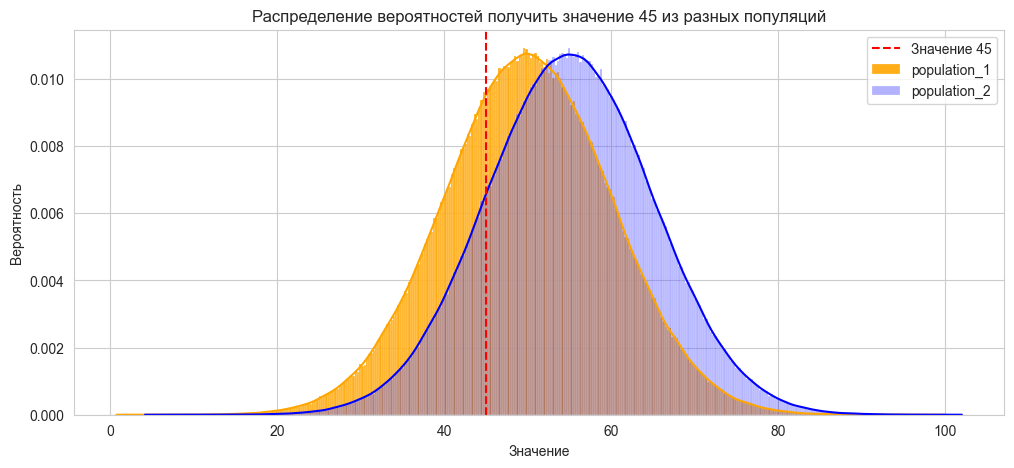

In [28]:
# Считаем вероятности получить значение из разных популяций
show_value(population_1, population_2, 45, **params)

# АА-Тест
Задача – посмотреть на симуляции сонаправленность pvalue и метода правдоподобия. Для этого проведем 10_000 АА-тестов c $H_{0}: A_{avg} = B_{avg}$. В каждом тесте будем:
1. Брать по 1_000 наблюдений в А/В (с возвратом); 
2. Считать: статистику (ср.знач), Т-тест, вероятность популяции при данной статистике;
3. Параметры теста зафиксируем классическими значениями: $\alpha=0.05,\; \beta=0.2$

Ожидание. Все тесты в которых мы не смогли отвергнуть $H_{0}$ будут иметь вероятность исходной популяции (`population_1`) при полученной статистике больше чем вероятность другой популяции (`population_2`). 

In [31]:
def run_simulation(sample_n, population, mu_1, sigma_1, mu_2, sigma_2):
    """ """

    choice = lambda x: np.random.choice(x, size=sample_n, replace=True)
    sample_a, sample_b = choice(population), choice(population)

    sample_a_avg, sample_b_avg = np.mean(sample_a), np.mean(sample_b)
    t_stat, p_value = stats.ttest_ind(sample_a, sample_b)

    # Считаем вероятность "значения из популяции/популяции при значении" 
    prob_a_true = stats.norm.pdf(sample_a_avg, loc=mu_1, scale=sigma_1)
    prob_a_false = stats.norm.pdf(sample_a_avg, loc=mu_2, scale=sigma_2)

    prob_b_true = stats.norm.pdf(sample_b_avg, loc=mu_1, scale=sigma_1)
    prob_b_false = stats.norm.pdf(sample_b_avg, loc=mu_2, scale=sigma_2)

    return sample_a_avg, sample_b_avg, t_stat, p_value, prob_a_true, prob_a_false, prob_b_true, prob_b_false

In [33]:
results = [
    run_simulation(sample_n=1_000, population=population_1, **params)
    for _ in tqdm(range(10_000), desc="Running simulations", unit="sim")
]

Running simulations: 100%|██████████| 10000/10000 [00:10<00:00, 917.23sim/s]


In [36]:
df = pd.DataFrame(
    results,
    columns=['sample_a_avg', 'sample_b_avg', 't_stat', 'p_value', 'prob_a_true', 'prob_a_false', 'prob_b_true', 'prob_b_false']
)

### Проверяем равномерность распределения pvalue

Не можем отклонить Н0. statistic:0.010276055240928672, pvalue:0.2399346516108719


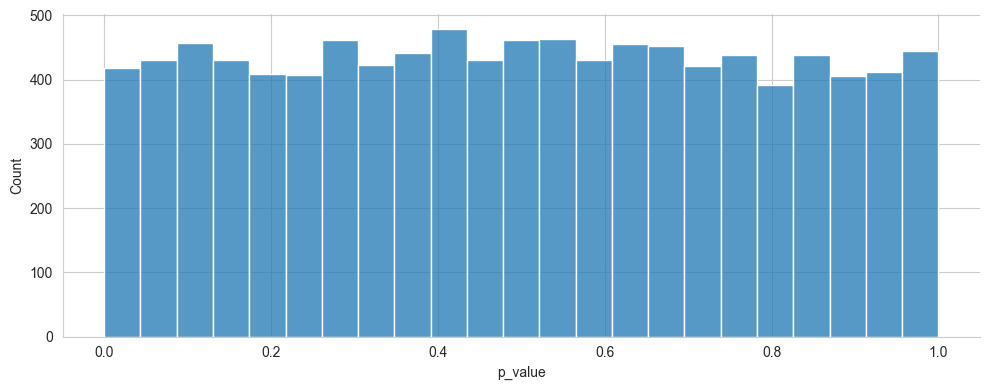

In [55]:
# Проверим равномерность распределения с помощью теста Колмогорова-Смирнова.
ks_stat, p_value = stats.kstest(df['p_value'], 'uniform')[:2]
if p_value >= 0.05:
    print(f'Не можем отклонить Н0. statistic:{ks_stat}, pvalue:{p_value}')

sns.displot(df['p_value'], aspect=2.5, height=4);

### Смотрим долю ошибок 1-го рода

In [72]:
df_error_one = df.query('p_value < 0.05')
df_error_one_rate = df_error_one.shape[0] / df.shape[0]
print(f'Доля ошибок первого рода в серии из {df.shape[0]} составила: {df_error_one_rate:.2%}')

Доля ошибок первого рода в серии из 10000 составила: 4.88%


In [75]:
# ХМ
df_error_one.query('prob_a_false > prob_a_true').shape[0]

0

## А если так?


In [76]:
params = {
    'mu_1': 50,
    'sigma_1': 10,
    'mu_2': 51,
    'sigma_2': 10,
}

Вероятность получить значение 45 из Популяции №1 : 3.52%
Вероятность получить значение 45 из Популяции №2 : 3.33%



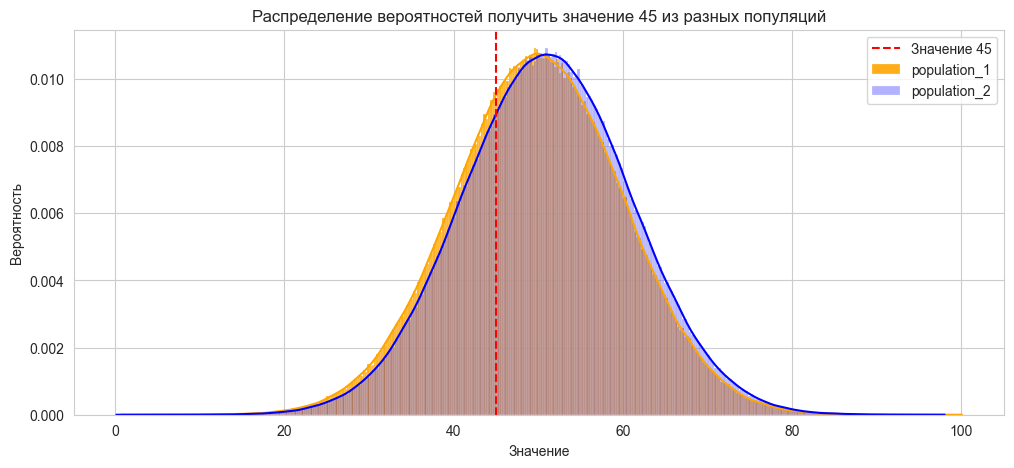

In [77]:
# Генерируем популяции 
population_1, population_2 = get_population(**params)
# Считаем вероятности получить значение из разных популяций
show_value(population_1, population_2, 45, **params)

In [78]:
results = [
    run_simulation(sample_n=1_000, population=population_1, **params)
    for _ in tqdm(range(10_000), desc="Running simulations", unit="sim")
]

Running simulations: 100%|██████████| 10000/10000 [00:10<00:00, 936.38sim/s]


In [79]:
df = pd.DataFrame(
    results,
    columns=['sample_a_avg', 'sample_b_avg', 't_stat', 'p_value', 'prob_a_true', 'prob_a_false', 'prob_b_true', 'prob_b_false']
)

Не можем отклонить Н0. statistic:0.006499204731467589, pvalue:0.7895653394796


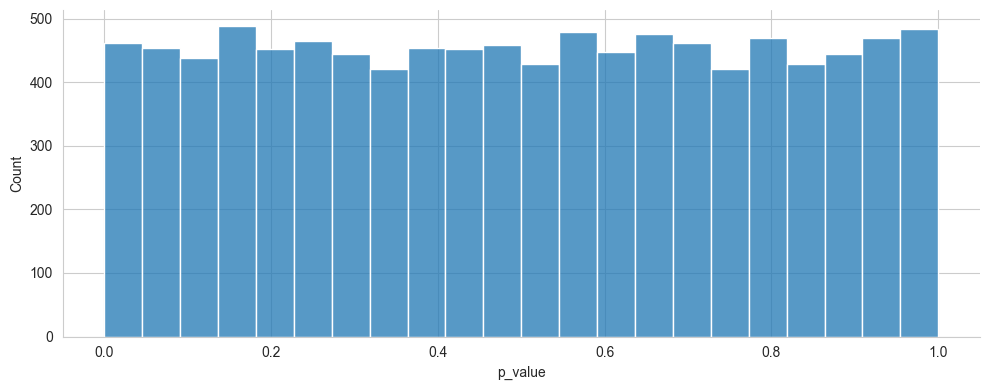

In [80]:
# Проверим равномерность распределения c помощью теста Колмогорова-Смирнова.
ks_stat, p_value = stats.kstest(df['p_value'], 'uniform')[:2]
if p_value >= 0.05:
    print(f'Не можем отклонить Н0. statistic:{ks_stat}, pvalue:{p_value}')

sns.displot(df['p_value'], aspect=2.5, height=4);

In [81]:
df_error_one = df.query('p_value < 0.05')
df_error_one_rate = df_error_one.shape[0] / df.shape[0]
print(f'Доля ошибок первого рода в серии из {df.shape[0]} составила: {df_error_one_rate:.2%}')

Доля ошибок первого рода в серии из 10000 составила: 5.10%


In [88]:
# Опа! Там, где мы ошибочно отклонили Н0 метод правдоподобия тоже ошибся. 
# Он посчитал, что population_2 более вероятна чем population_1
df_error_one.query('prob_a_true < prob_a_false').shape[0]

142

In [95]:
# А что с обратной историей? Есть у нас тесты, где мы не отклонили Н0, но метода правдоподобия говорит, что популяция не та?
# ХМ и как с этим жить?
df.query('p_value >= 0.05 and prob_a_true < prob_a_false').shape[0] / df.query('p_value >= 0.05').shape[0]

0.04657534246575343

In [96]:
from scipy.stats import pearsonr

In [97]:



# Пример: массивы p-value, prob_a_true, prob_a_false
p_values = np.array([...])
prob_a_true = np.array([...])
prob_a_false = np.array([...])

# Корреляция с prob_a_true
corr_true, _ = pearsonr(df['p_value'], df['prob_a_true'])

# Корреляция с prob_a_false
corr_false, _ = pearsonr(df['p_value'], df['prob_a_false'])

print(f'Корреляция с prob_a_true: {corr_true}')
print(f'Корреляция с prob_a_false: {corr_false}')


Корреляция с prob_a_true: 0.37464564032602643
Корреляция с prob_a_false: 0.07302864203859785


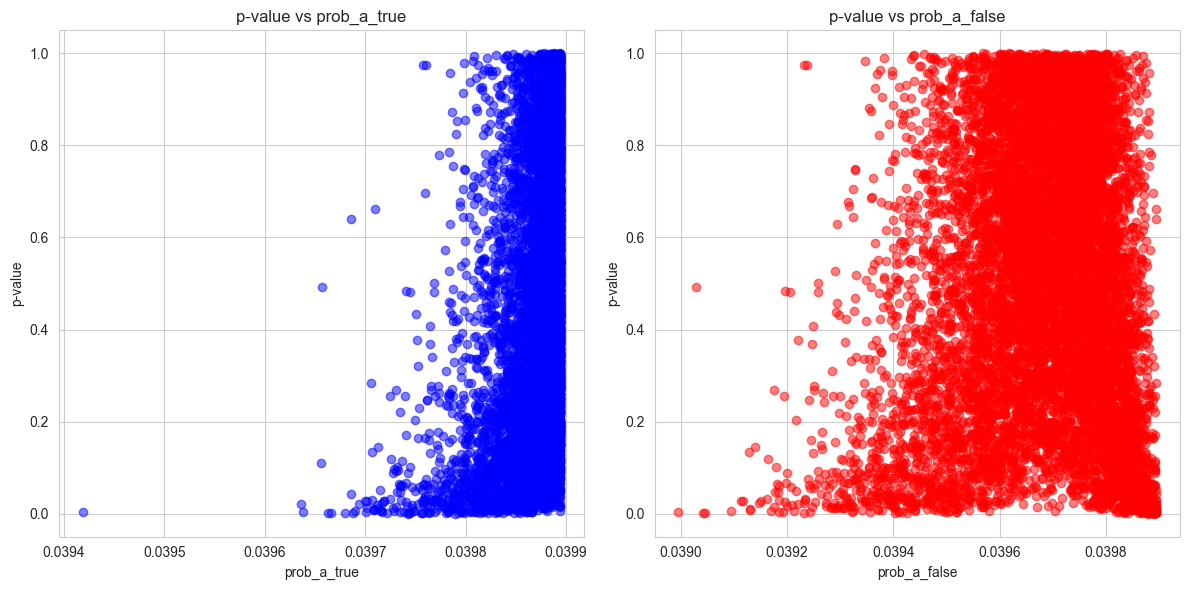

In [98]:
plt.figure(figsize=(12, 6))

# Подграфик 1: p-value vs prob_a_true
plt.subplot(1, 2, 1)
plt.scatter(df['prob_a_true'], df['p_value'], alpha=0.5, color='blue')
plt.title('p-value vs prob_a_true')
plt.xlabel('prob_a_true')
plt.ylabel('p-value')

# Подграфик 2: p-value vs prob_a_false
plt.subplot(1, 2, 2)
plt.scatter(df['prob_a_false'], df['p_value'], alpha=0.5, color='red')
plt.title('p-value vs prob_a_false')
plt.xlabel('prob_a_false')
plt.ylabel('p-value')

plt.tight_layout()
plt.show()

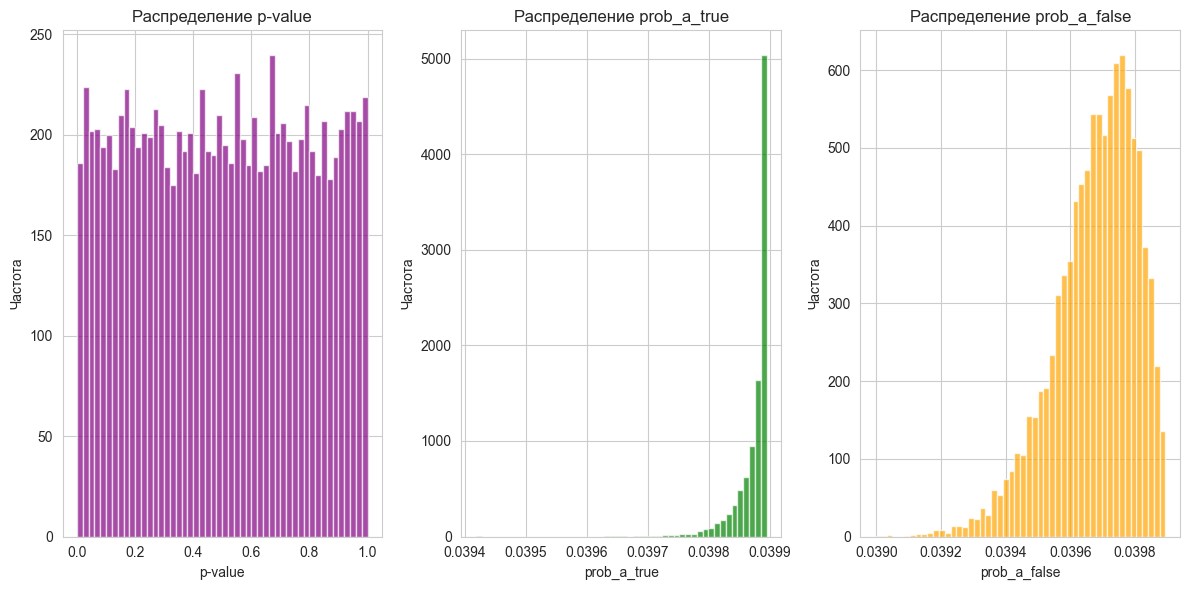

In [99]:
plt.figure(figsize=(12, 6))

# Гистограмма для p-value
plt.subplot(1, 3, 1)
plt.hist(df['p_value'], bins=50, alpha=0.7, color='purple')
plt.title('Распределение p-value')
plt.xlabel('p-value')
plt.ylabel('Частота')

# Гистограмма для prob_a_true
plt.subplot(1, 3, 2)
plt.hist(df['prob_a_true'], bins=50, alpha=0.7, color='green')
plt.title('Распределение prob_a_true')
plt.xlabel('prob_a_true')
plt.ylabel('Частота')

# Гистограмма для prob_a_false
plt.subplot(1, 3, 3)
plt.hist(df['prob_a_false'], bins=50, alpha=0.7, color='orange')
plt.title('Распределение prob_a_false')
plt.xlabel('prob_a_false')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()